# Cardiovascular Disease Prediction using Machine Learning

## Introduction

Cardiovascular diseases are among the leading causes of death worldwide. Early detection is important because it can help improve treatment and reduce serious health risks. In this project, machine learning is used to predict cardiovascular disease based on patient health information.

## Objective

The goal of this project is to analyze a cardiovascular disease dataset and train a model to predict whether a patient has cardiovascular disease.

## Dataset Description

The dataset was obtained from Kaggle and contains health and lifestyle information about patients. The target variable is `cardio`, where `0` means no disease and `1` means disease.

## Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step, we load the cardiovascular disease dataset into Python.

In [10]:
df = pd.read_csv("cardio_train.csv", sep=";")

## First Look at the Data

In [11]:
print(df.shape)
print(df.columns)
df.info()

(70000, 13)
Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [12]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


## Checking for Missing Values

In [13]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

## Data Preprocessing

In this section, age is converted from days to years, and the `id` column is removed because it does not help the prediction.

In [14]:
df["age_years"] = (df["age"] / 365).astype(int)
df = df.drop("id", axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47


## Inspecting Blood Pressure Values

Before plotting blood pressure, we inspect the summary statistics because medical variables may contain unrealistic values or data-entry errors.

In [15]:
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


## Handling Unrealistic Blood Pressure Values

The dataset contains some unrealistic values in the blood pressure columns. These extreme outliers can distort visualizations and affect model performance. Therefore, impossible values are filtered out before continuing the analysis.

In [16]:
df = df[(df["ap_hi"] > 0) & (df["ap_hi"] < 250)]
df = df[(df["ap_lo"] > 0) & (df["ap_lo"] < 200)]
df.shape

(68985, 13)

## Target Variable Analysis

In [17]:
df["cardio"].value_counts()

cardio
0    34844
1    34141
Name: count, dtype: int64

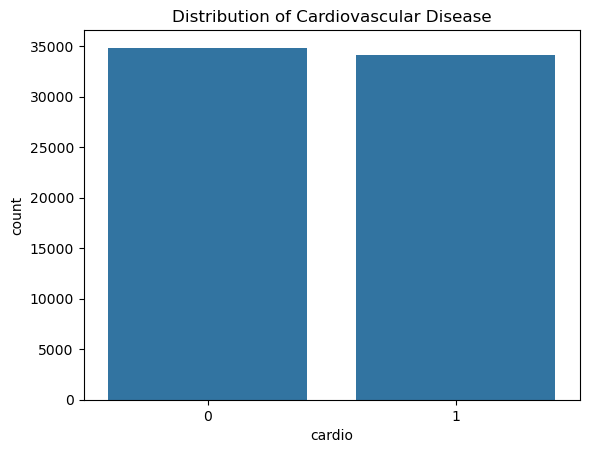

In [18]:
sns.countplot(x="cardio", data=df)
plt.title("Distribution of Cardiovascular Disease")
plt.show()

## Exploratory Data Analysis

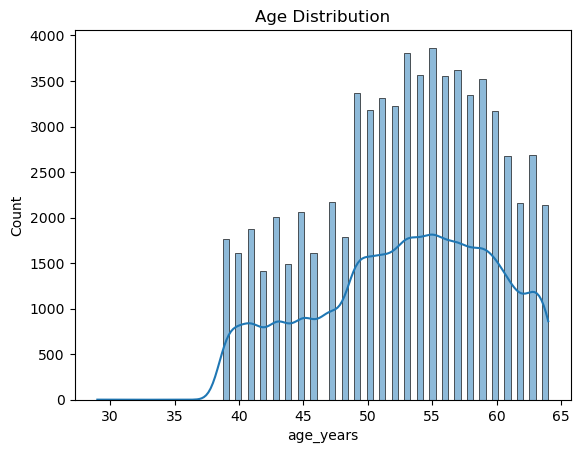

In [19]:
sns.histplot(df["age_years"], kde=True)
plt.title("Age Distribution")
plt.show()

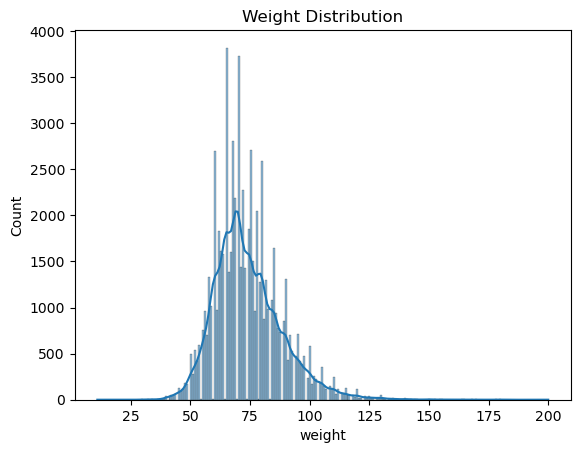

In [20]:
sns.histplot(df["weight"], kde=True)
plt.title("Weight Distribution")
plt.show()

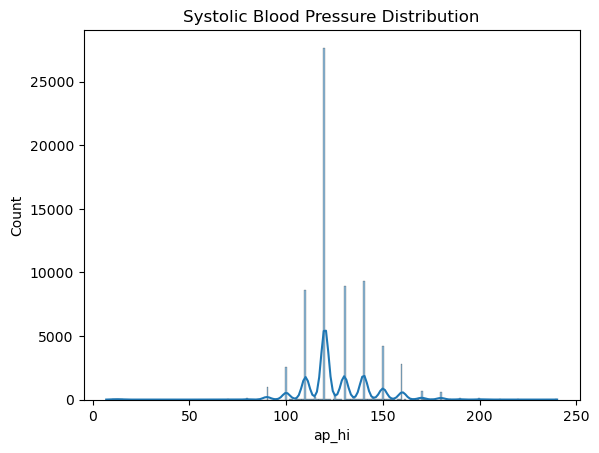

In [21]:
sns.histplot(df["ap_hi"], kde=True)
plt.title("Systolic Blood Pressure Distribution")
plt.show()

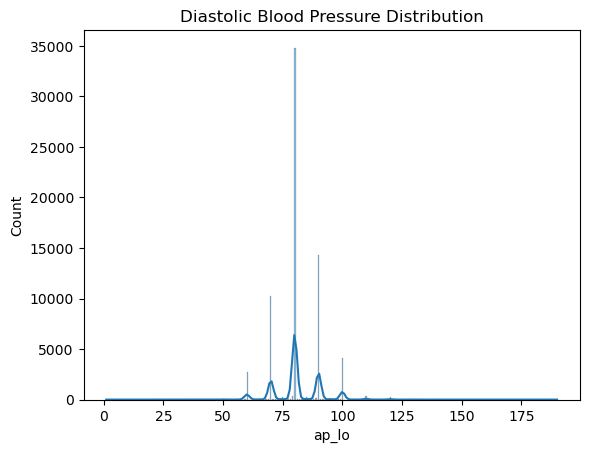

In [22]:
sns.histplot(df["ap_lo"], kde=True)
plt.title("Diastolic Blood Pressure Distribution")
plt.show()

## Defining Features and Target

In [23]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

## Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

We first scale the input features and then train a Logistic Regression model. Scaling is important because the dataset contains variables with different ranges, and Logistic Regression performs better when features are standardized.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

## Prediction

After training the model, we use it to predict the target values for the test data.

In [26]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

We evaluate the model using accuracy, classification report, and confusion matrix.

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7285641806189751
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6925
           1       0.75      0.67      0.71      6872

    accuracy                           0.73     13797
   macro avg       0.73      0.73      0.73     13797
weighted avg       0.73      0.73      0.73     13797

[[5421 1504]
 [2241 4631]]


## Interpretation of Results

The model was evaluated on the test set using accuracy, classification report, and confusion matrix. The accuracy score shows the overall percentage of correct predictions. The classification report gives more detailed information about precision, recall, and F1-score for each class. The confusion matrix shows how many cases were classified correctly and incorrectly.

## Conclusion

In this project, a cardiovascular disease dataset was analyzed and a machine learning model was used to predict the presence of disease. The notebook included data loading, preprocessing, handling unrealistic blood pressure values, visualization, model training, and evaluation. The results show that machine learning can be applied to healthcare-related prediction tasks and that proper preprocessing is important for obtaining meaningful results.

In [28]:
y_pred = model.predict(X_test_scaled)